# Assignment 1

## General information

Please give short (2-3 sentences) interpretations / explanations to your answers, not only the program code and outputs. Be concise and focused, especially in the AI-world. We take this seriously and will downgrade excessive verbosity. You should submit only the converted `.pdf` file to Moodle.

Grades will be distributed with the following rule: from the points you earn, you get 100% if you submit until the due date (**2026-02-25 12:00 CET**), 50% within 24 hours past due date, and 0% after that. 

## Task 1: Gene expression data (3 points)

From the ISLR website, we can download a **gene expression data** set (`Ch10Ex11.csv`) that consists of 40 tissue samples with measurements on 1,000 genes. The first 20 samples are from healthy patients, while the second 20 are from a diseased group.

We would have no chance to estimate any model on these 1,000 features. However, we could reduce the dimensionality with PCA. Then, we could look at the relation of the first few principal components (that captures part of the variance of all 1,000 features) and the outcome.

Note that as we only have 40 observations we can only define a subspace with at most 39 dimensions. Think of it like trying to define a volume in 3D space using only 2 points - you can only define a line, not a full 3D space. Technically, the sklearn PCA implementation will result in 40 components, but the last one will have a variance of 0.

In [3]:
# Load the data
import pandas as pd

# Read the CSV file
url = 'https://www.statlearning.com/s/Ch10Ex11.csv'
genes = pd.read_csv(url, header=None)

# Transpose the dataframe and convert to pandas DataFrame
genes = genes.T
genes = pd.DataFrame(genes)
print('Dimensions of genes dataframe:', genes.shape)

# Define health_status
health_status = ['healthy'] * 20 + ['diseased'] * 20

Dimensions of genes dataframe: (40, 1000)


<div style="page-break-after: always"></div>

### Questions

1. Compute the variance of each feature and plot a histogram of those variances. Based on the histogram, are the features similarly scaled? Would you standardize the features before applying PCA? Explain your reasoning. (*Hint*: treat features as similarly scaled if their variances differ by at most an order of magnitude.)



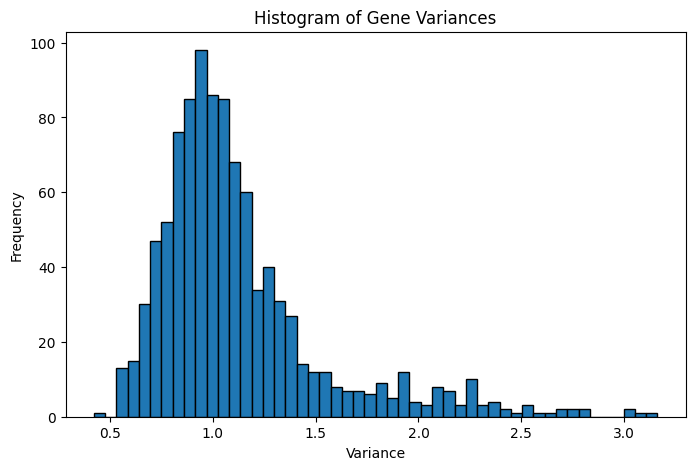

Max variance: 3.1610, Min variance: 0.4230
Ratio (Max/Min): 7.47


In [7]:
import matplotlib.pyplot as plt

# Compute variances
variances = genes.var(axis=0)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(variances, bins=50, edgecolor='black')
plt.title('Histogram of Gene Variances')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.show()

# Check order of magnitude
max_var = variances.max()
min_var = variances.min()
print(f"Max variance: {max_var:.4f}, Min variance: {min_var:.4f}")
print(f"Ratio (Max/Min): {max_var / min_var:.2f}")

Through histogram analysis and extreme value calculations, it can be observed that the ratio of the maximum to minimum gene variance is 7.47. Given the similarity in feature scales, PCA can be performed directly.

###
2. Apply PCA to the full dataset. How many principal components are required to explain at least 90\% of the total variance? How much variance is captured by the first two principal components?

In [8]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(genes)

# Calculate explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
var_first_two = cumulative_variance[1]

print(f"Components for 90% variance: {n_components_90}")
print(f"Variance captured by first two PCs: {var_first_two * 100:.2f}%")

Components for 90% variance: 33
Variance captured by first two PCs: 15.94%


The cumulative variance contribution array indicates that 33 principal components are required to explain at least 90% of the total variance. The first two principal components together capture 15.94% of the data variance.

###
3. Create a scatter plot of the first two component scores (the data projected onto the first two principal components). Color the points by patient health status. Do these components help distinguish healthy from diseased patients? Which component separates the groups more clearly?

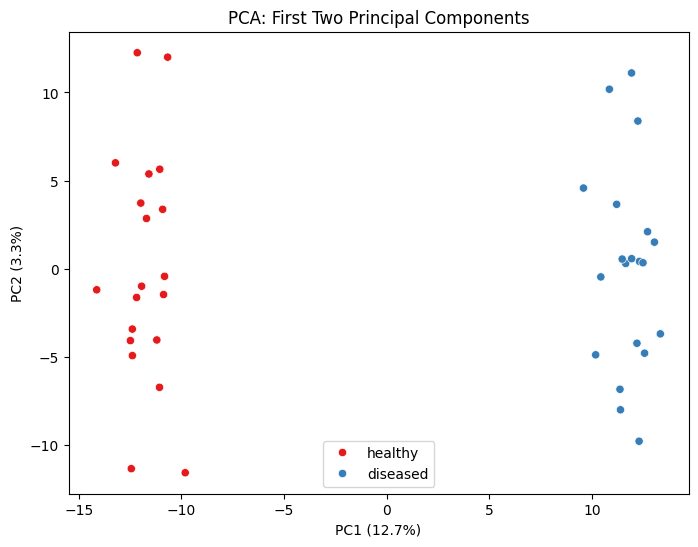

In [10]:
import seaborn as sns

# Transform data onto the first two PCs
scores = pca.transform(genes)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=health_status, palette='Set1')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA: First Two Principal Components")
plt.show()

The scatter plot of the first two principal components effectively distinguishes healthy and diseased samples. Observing the chart reveals that the first principal component (PC1 axis) most clearly separates the healthy and diseased groups, explaining 12.7% of the total variance.

###
4. For the principal component that best separates healthy and diseased patients, identify the genes with the largest absolute loadings (the strongest contributors). Briefly describe how you selected them. (*Hint*: examine the component loadings.)

In [11]:
pc1_loadings = pd.Series(pca.components_[0], index=genes.columns)
top_genes = pc1_loadings.abs().nlargest(10)

print("Genes with the largest absolute loadings on the separating component:")
print(top_genes)

Genes with the largest absolute loadings on the separating component:
599    0.114243
583    0.110398
548    0.108329
539    0.108125
501    0.107460
581    0.106549
564    0.106271
567    0.106188
528    0.104163
598    0.103821
dtype: float64


By calculating the absolute values of all genes' loadings on this principal component and sorting them in descending order, the top 10 genes by absolute value were selected. These genes exhibit the highest weight in this projection direction, indicating they show the most significant expression variation between the two populations.

## Task 2: PCA on simulated data (3 points)

In this exercise, you will work on simulated features. This simulated data have **mixed correlation structure**: some features cluster together (correlated), while others are independent.

In [12]:
# Data generation with mixed correlation structure
import numpy as np

rng = np.random.default_rng(seed=20260218)  # for reproducibility
n = 100
p = 50

# Create 5 groups of 10 correlated features each
# Within each group, features are correlated with each other
# Between groups, features are independent

X = np.zeros((n, p))

# Generate 5 independent latent factors (one per group)
n_groups = 5
features_per_group = 10
latent_factors = rng.normal(loc=0.0, scale=1.0, size=(n, n_groups))

for group in range(n_groups):
    start_idx = group * features_per_group
    end_idx = start_idx + features_per_group
    
    # Each feature in the group is the latent factor plus independent noise
    # This creates correlation within the group
    for i in range(features_per_group):
        noise = rng.normal(loc=0.0, scale=0.5, size=n)  # smaller noise = higher correlation
        X[:, start_idx + i] = latent_factors[:, group] + noise

print(f'Generated data shape: {X.shape}')
print(f'Data structure: {n_groups} groups of {features_per_group} correlated features each')

Generated data shape: (100, 50)
Data structure: 5 groups of 10 correlated features each


<div style="page-break-after: always"></div>

### Questions

1. Compute the correlation matrix of the generated features and visualize it as a heatmap. Describe the correlation structure you observe. Does it match the data-generating process?



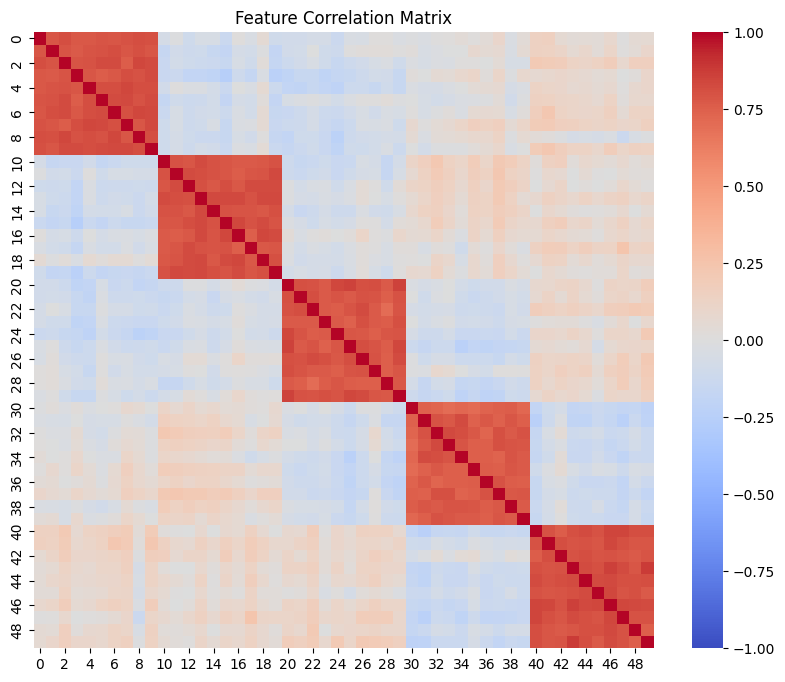

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Correlation Matrix
corr_matrix = np.corrcoef(X, rowvar=False)

# Heatmap Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

The heatmap clearly displays five 10x10 blocks of bright colors along the diagonal, indicating high correlations, while areas outside these blocks show correlation coefficients close to zero. This signifies the identification of five mutually independent latent factor clusters, each containing ten features that are highly correlated internally.

###
2. Run PCA on the full dataset (100 samples, 50 features). How many components are needed to explain at least 90% of the variance? 


In [14]:
from sklearn.decomposition import PCA

pca_sim = PCA()
pca_sim.fit(X)

# Number of principal components required to account for 90% of variance
cum_var_sim = np.cumsum(pca_sim.explained_variance_ratio_)
n_components_90_sim = np.argmax(cum_var_sim >= 0.90) + 1

print(f"Components needed for 90% variance: {n_components_90_sim}")

Components needed for 90% variance: 15


After performing PCA analysis on the entire 100x50 dataset, the cumulative variance contribution rate indicates that 15 principal components are required to explain at least 90% of the total variance.

###

3. Plot the explained variance ratio for the first 20 components. What does the shape of this curve tell you about the data structure? (*Hint*: look for an "elbow" or plateaus in the curve.)



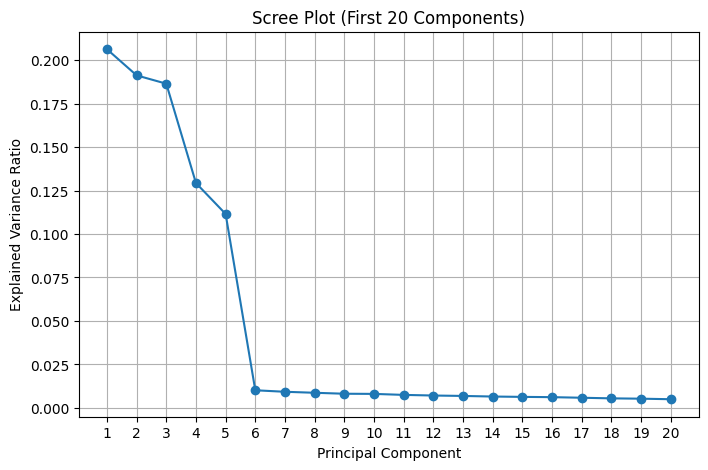

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), pca_sim.explained_variance_ratio_[:20], marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot (First 20 Components)')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

The variance explained curve for the top 20 principal components exhibits a steep decline after the sixth principal component, followed by a plateau phase. This indicates that variance is primarily driven by five core latent factors, with the remaining principal components capturing mainly random noise.

###
4. Split the data into 80–20% train/test sets. For a range of component counts, compute reconstruction errors on both sets like we did in class. Plot these errors. Based on the plot, how many components would you choose to best summarize this dataset?

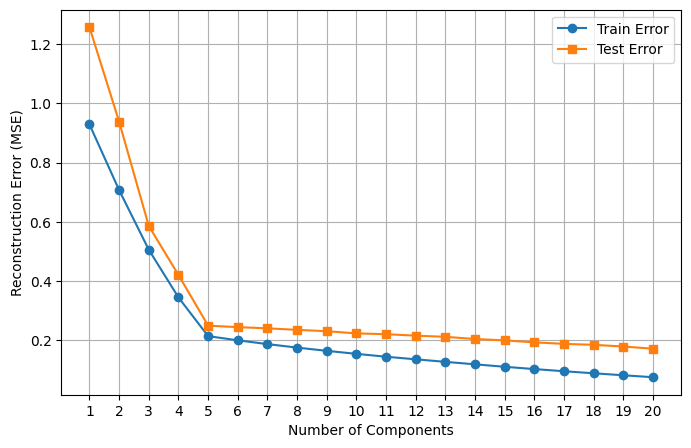

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# split
X_train, X_test = train_test_split(X, test_size=0.20, random_state=20260218)

max_comp = 20
train_errors, test_errors = [], []

# Reconstruction Error at Different Numbers of Principal Components
for k in range(1, max_comp + 1):
    pca_k = PCA(n_components=k)
    pca_k.fit(X_train)
    
    # Training set error
    X_train_rec = pca_k.inverse_transform(pca_k.transform(X_train))
    train_errors.append(mean_squared_error(X_train, X_train_rec))
    
    # Test set error
    X_test_rec = pca_k.inverse_transform(pca_k.transform(X_test))
    test_errors.append(mean_squared_error(X_test, X_test_rec))

# Plot error plots
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_comp + 1), train_errors, marker='o', label='Train Error')
plt.plot(range(1, max_comp + 1), test_errors, marker='s', label='Test Error')
plt.xlabel('Number of Components')
plt.ylabel('Reconstruction Error (MSE)')
plt.legend()
plt.xticks(range(1, max_comp + 1))
plt.grid(True)
plt.show()

The reconstruction error plot shows that both training and testing errors decrease sharply until the number of principal components reaches 5, after which the testing error curve levels off. Based on this, selecting 5 principal components best summarizes the dataset, capturing the core structure while avoiding overfitting to noise.


## Task 3: PCA on uncorrelated features (4 points)

In this task you will simulate data where the data-generating process has **no correlations** between features (in math terms: the population covariance is the identity matrix).


In [17]:
# Data generation
import numpy as np

rng = np.random.default_rng(seed=20260218)  # for reproducibility
n = 100
p = 50
X = rng.normal(loc=0.0, scale=1.0, size=(n, p))  # population covariance = I_p

<div style="page-break-after: always"></div>

### Questions

1. Run PCA on the generated data (100 samples, 50 features). How many components are needed to explain at least 90% of the variance? Does this match your theoretical expectation given the data-generating process? (*Hint*: looking at the correlation heatmap like you did in the previous task could help.)



In [18]:
from sklearn.decomposition import PCA
import numpy as np

# Data generation
rng = np.random.default_rng(seed=20260218)
n, p = 100, 50
X = rng.normal(loc=0.0, scale=1.0, size=(n, p))

# Fit PCA
pca_uncorr = PCA()
pca_uncorr.fit(X)

# Calculate components for 90% variance
cum_var = np.cumsum(pca_uncorr.explained_variance_ratio_)
n_comp_90 = np.argmax(cum_var >= 0.90) + 1

print(f"Components needed for 90% variance (full data): {n_comp_90}")

Components needed for 90% variance (full data): 34


PCA analysis of the entire dataset with no correlations revealed that as many as 34 principal components were required to explain 90% of the variance. This aligns with theoretical expectations: when the population covariance matrix is the identity matrix, no low-dimensional manifold can summarize the data, and each principal component captures only spurious correlations generated by the finite sample size.

###
2. Split the data into an 80–20% train/test split. Fit PCA using the *train* set only. How many components are required to explain at least 90% of the variance on the training set? Compute the reconstruction error on the training set like we did in class and explain the result. Then, compute the reconstruction error on the test set and compare it to the training error.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Train/Test Split
X_train, X_test = train_test_split(X, test_size=0.20, random_state=20260218)

# Fit PCA on train set only
pca_train = PCA()
pca_train.fit(X_train)

# Components for 90% variance on train set
cum_var_train = np.cumsum(pca_train.explained_variance_ratio_)
n_train_90 = np.argmax(cum_var_train >= 0.90) + 1
print(f"Components for 90% variance (train): {n_train_90}")

# Reconstruction errors at n_train_90
pca_90 = PCA(n_components=n_train_90).fit(X_train)
train_error = mean_squared_error(X_train, pca_90.inverse_transform(pca_90.transform(X_train)))
test_error = mean_squared_error(X_test, pca_90.inverse_transform(pca_90.transform(X_test)))

print(f"Train Error: {train_error:.4f}")
print(f"Test Error: {test_error:.4f}")

Components for 90% variance (train): 32
Train Error: 0.0942
Test Error: 0.3400


It requires 32 principal components to explain 90% of the variance. While retaining 32 principal components yields an extremely low reconstruction error in the training set (approximately 0.094), the reconstruction error in the test set increases significantly (approximately 0.340). This severe generalization error gap demonstrates that PCA has overfitted to completely random noise data.

###
3. For a range of component counts, compute reconstruction error on both train and test sets. Are the first few principal components equally effective on the test set as on the train set? Explain any differences.



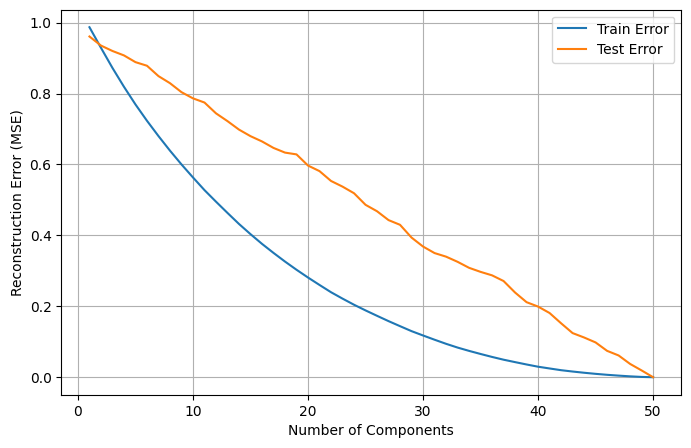

In [21]:
import matplotlib.pyplot as plt

train_errors, test_errors = [], []
max_comp = min(X_train.shape) # 50

for k in range(1, max_comp + 1):
    pca_k = PCA(n_components=k).fit(X_train)
    
    # Train error
    X_train_rec = pca_k.inverse_transform(pca_k.transform(X_train))
    train_errors.append(mean_squared_error(X_train, X_train_rec))
    
    # Test error
    X_test_rec = pca_k.inverse_transform(pca_k.transform(X_test))
    test_errors.append(mean_squared_error(X_test, X_test_rec))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_comp + 1), train_errors, label='Train Error')
plt.plot(range(1, max_comp + 1), test_errors, label='Test Error')
plt.xlabel('Number of Components')
plt.ylabel('Reconstruction Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In terms of the reduction in error, the performance of the first few principal components on the test set is less effective than on the training set. The fundamental reason for this discrepancy is that the data is completely random and uncorrelated. The “first few directions of maximum variance” extracted by PCA merely overfit the random noise within the training set samples and fail to generalize to the test set.

###
4. Compare your findings across all three tasks: 
   - Task 1 (gene expression): high-dimensional real data
   - Task 2 (partial correlation): mixed structure
   - Task 3 (uncorrelated): no correlation structure  
   
   In which scenario is PCA most effective for dimensionality reduction? Explain why correlation structure matters for PCA's effectiveness.

PCA dimension reduction is most effective in scenarios like Task 1 (high-dimensional data with numerous co-expressed genes) and Task 2 (mixed-structure data with internally correlated groups), as in both cases a small number of principal components can explain the vast majority of variance. However, when features are completely independent and uncorrelated (as in Task 3), no shared structure exists in the data that can be compressed. Consequently, PCA merely fits the random noise of a finite sample, losing its dimensionality reduction significance.